<a href="https://colab.research.google.com/github/antohachekhov/Credit-Card-Fraud/blob/main/eda_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection

**Цель проекта**: построить модель для выявления мошеннических транзакций по кредитным картам.


# Данные
Датасет взят с платформы Kaggle ([ссылка на датасет](https://www.kaggle.com/datasets/dhanushnarayananr/credit-card-fraud)). Этот датасет получен неназванным институтом.

Данные сильно несбалансированы - мошеннические транзакции составляют <1%.

In [1]:
# Чтение данных
from google.colab import drive
import pandas as pd

drive.mount('/content/drive') # подключение облачного хранилища Google Drive
pathToDataset = "/content/drive/MyDrive/card_transdata.csv"
dataset = pd.read_csv(pathToDataset)

Mounted at /content/drive


## Описание признаков

*   distance_from_home - дистанция от дома до места совершения транзакции
*   distance_from_last_transaction - дистанция от прошлого места совершения транзакции
*   ratio_to_median_purchase_price - отношение цены транзакции к медианной цене транзакций, совершенных ранее
*   repeat_retailer - была ли транзакция совершена с тем же продавцом ранее (0 - нет, 1 - да)
*   used_chip - была ли транзакция совершена с помощью чипа, т.е. кредитной карты (0 - нет, 1 - да)
*   used_pin_number - была ли транзакция совершена с введением PIN-кода (0 - нет, 1 - да)
*   online_order - является ли транзакция онлайн-покупкой (0 - нет, 1 - да)
*   fraud - является ли транзакция мошеннической (0 - нет, 1 - да)

In [3]:
dataset.iloc[:, 3:] = dataset.iloc[:, 3:].astype('category') # приведение признаков к категориальному типу
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype   
---  ------                          --------------    -----   
 0   distance_from_home              1000000 non-null  float64 
 1   distance_from_last_transaction  1000000 non-null  float64 
 2   ratio_to_median_purchase_price  1000000 non-null  float64 
 3   repeat_retailer                 1000000 non-null  category
 4   used_chip                       1000000 non-null  category
 5   used_pin_number                 1000000 non-null  category
 6   online_order                    1000000 non-null  category
 7   fraud                           1000000 non-null  category
dtypes: category(5), float64(3)
memory usage: 27.7 MB


Набор данных содержит 1 000 000 записей без пропусков по 8 признакам.

Признаки `distance_from_home`, `distance_from_last_transaction` и `ratio_to_median_purchase_price` являются количественным признакими - вещественные неотрицаительные числа.

Признаки `repeat_retailer`, `used_chip`, `used_pin_number`, `online_order` и `fraud` - категориальные признаки по дихотомической шкале (0 или 1).

**Целевой признак - `fraud`.**

In [4]:
# Получим списки названий количественных и категориальных признаков
numeric_features = dataset.select_dtypes(include=['number']).columns.tolist()
categorical_features = dataset.select_dtypes(include=['category']).columns.tolist()
objective_feature = 'fraud'

# EDA

## Статистические характеристики

**Статистические характеристики для числовых признаков**

In [5]:
dataset[numeric_features].describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price
count,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182
std,65.390784,25.843093,2.799589
min,0.004874,0.000118,0.004399
25%,3.878008,0.296671,0.475673
50%,9.967760,0.998650,0.997717
75%,25.743985,3.355748,2.096370
max,10632.723672,11851.104565,267.802942


В 75% случаев люди совершают покупки недалеко - в не более чем 26 км от дома и не более чем 4 км от места прошлой покупки.

Обычно люди совершают покупки на сумму, примерно равную медиане всех их покупок. В 75% случаев сумма покупки не превышает примерно двойное значение медианы их покупок.

Можно заметить, что у всех числовых признаков среднее больше медианы (более того, у признаков `distance_from_home` и `distance_from_last_transaction` среднее больше верхнего квартиля). А также максимальные значения во много раз превышают верхний квартиль.

Следовательно, можно сделать следующие выводы:

- большинство транзакций сосредоточено в области малых значений признаков, тогда как крупные значения являются редкими и могут соответствовать аномальным (в том числе мошенническим) операциям;
- распределения признаков имеют тяжелые правые хвосты.

Из-за огромного размаха значений признаков, возможно потребуется лог-преобразование признаков. При подборе модели обучения лучше выбирать модель, устойчивую к выбросам.



**Статистические характеристики для категориальных данных**

In [6]:
dataset[categorical_features].describe()

,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.0,1000000.0,1000000.0,1000000.0,1000000.0
unique,2.0,2.0,2.0,2.0,2.0
top,1.0,0.0,0.0,1.0,0.0
freq,881536.0,649601.0,899392.0,650552.0,912597.0


Покупатели чаще всего совершают транзакции у знакомого продавца, без использования чип-карт, без ввода пин-кода, в онлайн-магазинах.

Доля мошеннических транзакций составляет около 8.7%. Следовательно, в данных сильный дисбаланс классов.

## Диаграммы размаха

Определение границ выбросов для количественных признаков по методу Тьюки и подсчёт доли выбросов

In [7]:
Q1 = dataset[numeric_features].quantile(0.25)
Q3 = dataset[numeric_features].quantile(0.75)
IQR = Q3 - Q1

bounds = pd.DataFrame({
    "lower_bound": Q1 - 1.5 * IQR,
    "upper_bound": Q3 + 1.5 * IQR
})

outlier_ratio = []
for col in numeric_features:
    lower = bounds.loc[col, "lower_bound"]
    upper = bounds.loc[col, "upper_bound"]
    outliers = ((dataset[col] < lower) | (dataset[col] > upper)).mean()
    outlier_ratio.append(outliers)
bounds["outlier_ratio"] = outlier_ratio
bounds

,lower_bound,upper_bound,outlier_ratio
distance_from_home,-28.920958,58.542951,0.103631
distance_from_last_transaction,-4.291945,7.944363,0.124367
ratio_to_median_purchase_price,-1.955372,4.527416,0.084386


В среднем выбросы составляют 10% выборки, что является не малой частью.

Построим диаграммы размаха.

С логарифмической шкалой:

In [5]:
import numpy as np
import matplotlib.pyplot as plt

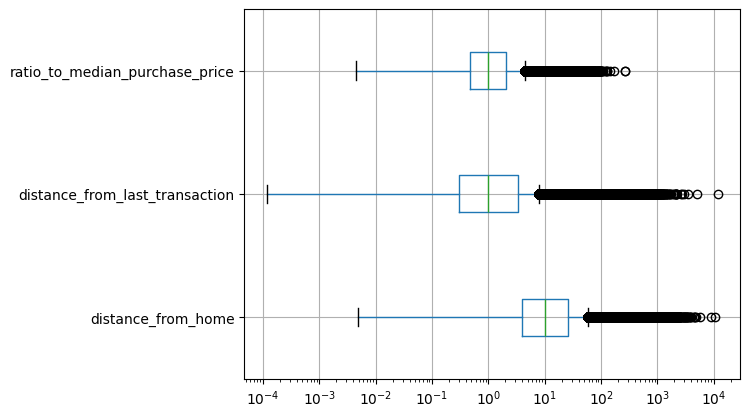

In [8]:
box = dataset[numeric_features].boxplot(vert=False)
box.set_xscale('log')
plt.show()

С обычной шкалой, обрезав выбросы

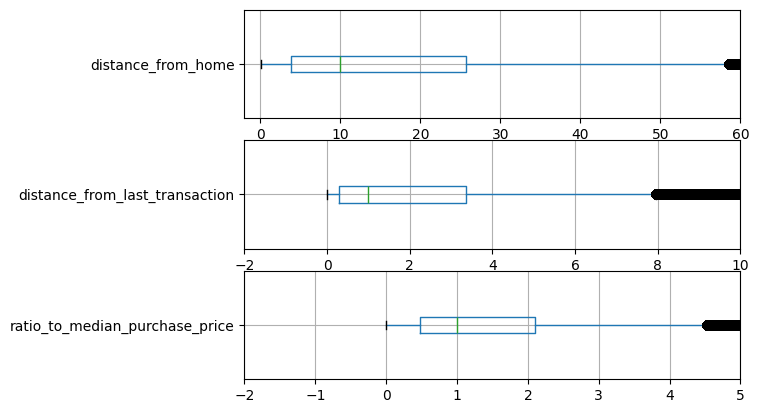

In [9]:
fig, axes = plt.subplots(3, 1)
boxes = [dataset.boxplot(numeric_features[i], vert=False, ax=axes[i]) for i in range(3)]

round_to_5 = lambda x: round(x / 5) * 5
for col, b in zip(numeric_features, boxes):
  b.set_xlim(left=-2, right=round_to_5(bounds.loc[col, "upper_bound"]))
plt.show()

Количественные признаки имеют скошенные вправо распределения с длинными правыми хвостами, что указывает на наличие экстремальных значений. Наблюдается, что медианы распределений более смещены влево, т.е. можно сделать вывод, что "типичные" транзакции имеют относительно небольшие значения признаков.

## Парные диаграммы

In [6]:
import seaborn as sns

# Сделаем копию датасета, содержащую значения числовых признаков после лог-преобразования
dataset_log1p = dataset[numeric_features + ['fraud']].copy()
for col in numeric_features:
    dataset_log1p[col] = np.log1p(dataset[col]) # сделаем лог-преобразование log(1+x),
                                                # чтобы сохранить строгую положительность признаков

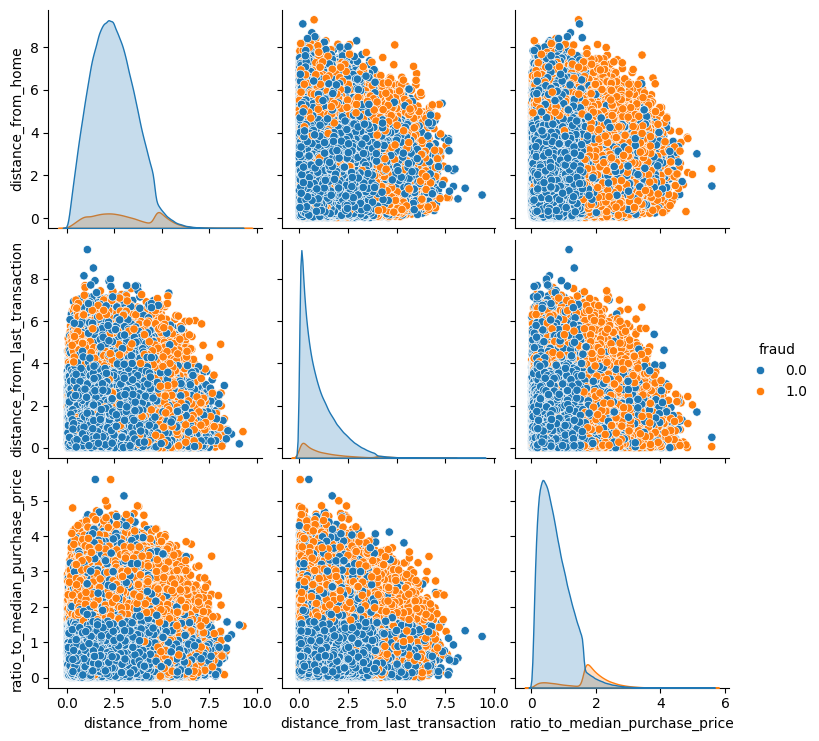

In [72]:
sns.pairplot(dataset_log1p, hue="fraud")

Классы не полностью разделимы.

По всем диаграммам видно, что мошеннические транзакции чаще всего соответствуют большим значениям признаков. При небольших значениях признаков парные диаграммы содержат почти только синие точки (не мошенническая транзакция).

Особенно заметно, что существует некоторая граница признака `ratio_to_median_purchase_price`, при которой частота мошеннических транзакций резко увеличивается. Это также видно по графику распределения `fraud` для этого признака - при резком уменьшении `fraud=0` происходит резкий скачок `fraud=1`.

Ещё наблюдение - нет таких данных, содержащие огромные значения любой пары признаков одновременно. Все диаграммы похожи на треугольники -  при увеличении одного признака другой уменьшается. Следовательно, можно подозревать, что существует зависимость между признаками.

## Графики квантиль-квантиль

Проверим подчиняются ли признаки ряду распределений.

1. Нормальное распределение

In [7]:
import scipy.stats as stats

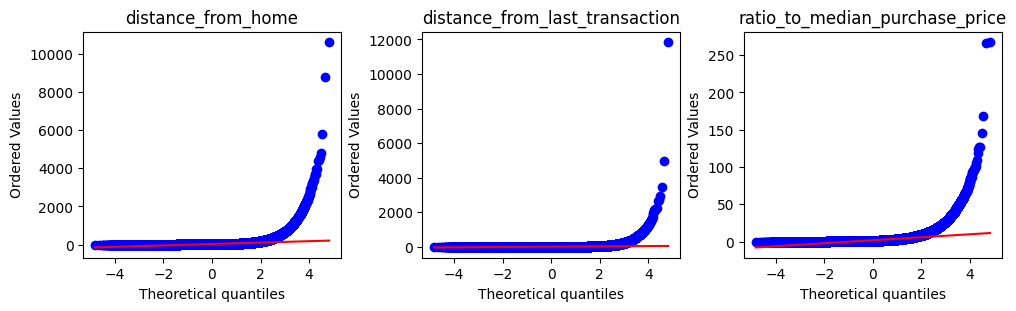

In [13]:
fig, axis = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)
for i, feature in enumerate(numeric_features):
  stats.probplot(dataset[feature], dist="norm", plot=axis[i])
  axis[i].set_title(feature)
plt.show()

Из-за тяжелых правых хвостов нельзя утверждать, что распределения признаков являются нормальными

2. Нормальному распределению после преобразования $\log(x+1)$

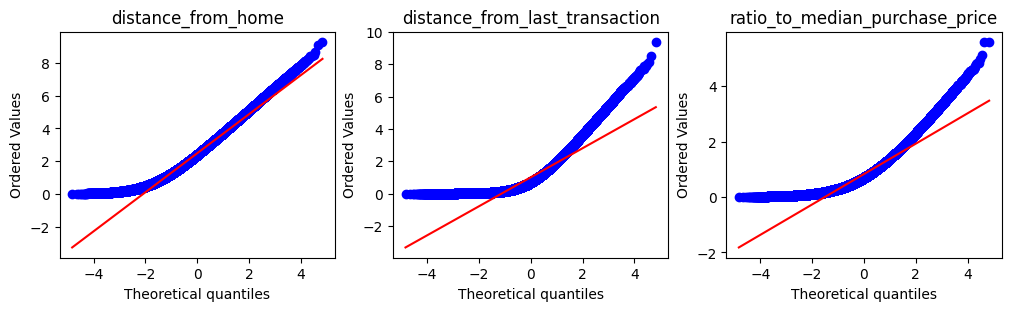

In [15]:
fig, axis = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)
for i, feature in enumerate(numeric_features):
  stats.probplot(dataset_log1p[feature], dist="norm", plot=axis[i])
  axis[i].set_title(feature)
plt.show()

Как видно, после преобразования $\log(1+x)$ признаки не подчиняются нормальному распределению.

3. Логнормальному распределению

Как известно, если $Y=\ln(X)\sim\mathcal{N}(\mu,\sigma)$, то $X\sim\text{LogNorm}(\mu,\sigma)$. Чтобы проверить признаки на логнормальность, нужно сделать лог-преобразование вида $\log(x)$

In [8]:
# сделаем лог-преобразование вида log(x) для числовых признаков
dataset_log = dataset[numeric_features + ['fraud']].copy()
for col in numeric_features:
    dataset_log[col] = np.log(dataset[col])

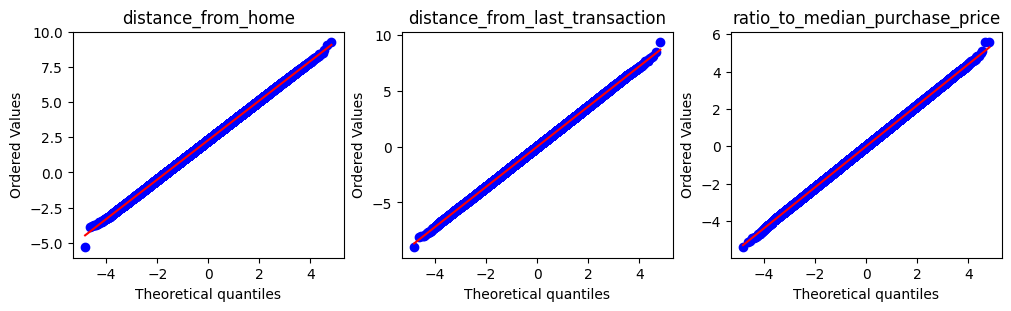

In [16]:
fig, axis = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)
for i, feature in enumerate(numeric_features):
  stats.probplot(dataset_log[feature], dist="norm", plot=axis[i])
  axis[i].set_title(feature)
plt.show()

Как видно, график квантиль-квантиль практически имеет форму прямой кривой. Следовательно, можно утвержать, что распределение всех числовых признаков очень близко к логнормальному распределению.

Посчитаем оценки параметров распределений празнаков:

In [38]:
for feature in numeric_features:
  print(feature)
  print(f'mean: {dataset_log[feature].mean()}\tstd: {dataset_log[feature].std()}\n')

distance_from_home
mean: 2.3005518671829286	std: 1.4016574094446639

distance_from_last_transaction
mean: -0.002715988136237382	std: 1.7993864607684393

ratio_to_median_purchase_price
mean: -0.0018716709892106186	std: 1.098468215466887



## Точечные графики

Построим точечные графики зависимости числовых признаков от факта мошеннической транзакции.

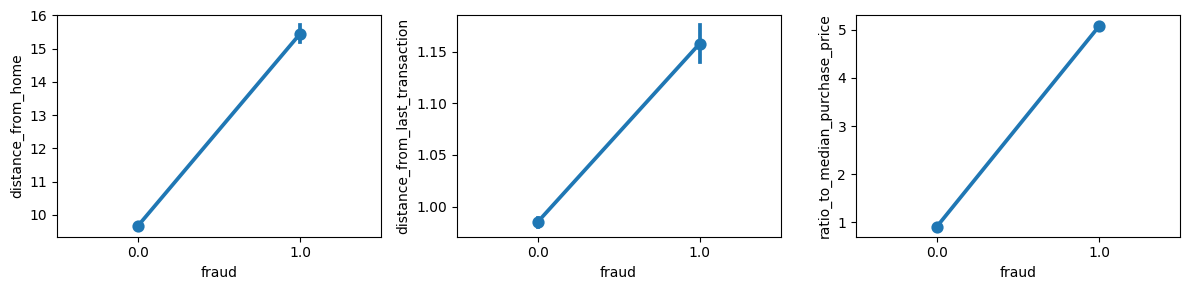

In [51]:
fig, axis = plt.subplots(1, 3, figsize=(12, 3))
for i, feature in enumerate(numeric_features):
  sns.pointplot(x="fraud", y=feature, data=dataset, ax=axis[i], estimator=np.median)
plt.tight_layout() # автоматически увеличить отступы между графиками
plt.show()

Выводы:
- мошенническая транзакция более вероятна при более сильной дистанции от дома клиента;
- мошенническая транзакция более вероятна при более сильной дистанции от места последней транзакция, хотя и не на большое значение;
- мошенническая транзакция более вероятна при значении признака `ratio_to_median_purchase_price`, большем чем 1. **Наиболее сильное изменение.**

Теперь построим точечные графики для категориальных признаков - как меняется вероятность мошеннической транзакции от значений этих признаков.

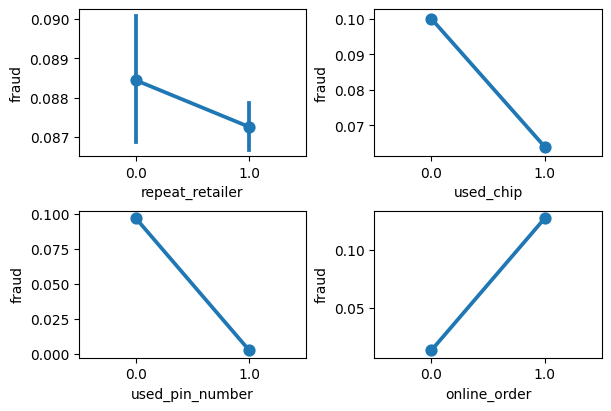

In [19]:
fig, axis = plt.subplots(2, 2, figsize=(6, 4), constrained_layout=True)
for i, feature in enumerate([c for c in categorical_features if c != objective_feature]):
  sns.pointplot(x=feature, y=objective_feature, data=dataset, ax=axis[i // 2, i % 2])
  axis[i // 2, i % 2].invert_yaxis() # инверсия оси Y
plt.show()

Выводы:
- вероятность мошеннической транзакции сильнее, если транзакция совершена у нового продавца, чем у знакомого. Но эта разность совсем небольшая.
- вероятность мошеннической транзакции больше, если транзакция совершена без использования чипа, на 3%.
- **если был использован пин-код, вероятность мошенничества почти нулевая.** Если пин-код не был использован, вероятность мошенничества растёт на 10%.
- вероятность мошенничества выше при онлайн-заказах примерно на 10%.

Таким образом, онлайн-заказы повышают риск мошенничества, а использование пин-кода и чипа - уменьшают. `repeat_retailer` имеет практически слабую связь с целевым признаком.

## Сводные таблицы

С помощью сводных таблиц посчитаем условные вероятности мошеннических транзакций при разных значениях всех пар категориальных признаков.

In [22]:
dataset["fraud"] = dataset["fraud"].astype(int)
dataset.pivot_table(values="fraud", index="online_order", columns="used_chip", aggfunc="mean", observed=True)

used_chip,0.0,1.0
online_order,,
0.0,0.017101,0.006621
1.0,0.144593,0.094773


Факт онлайн-покупки повышает риск мошеннической транзакции. Использование чипа уменьшает этот риск, однако он не компенсирует полностью риск при онлайн-покупках.

In [23]:
dataset.pivot_table(values="fraud", index="repeat_retailer", columns="used_chip", aggfunc="mean", observed=True)

used_chip,0.0,1.0
repeat_retailer,,
0.0,0.099535,0.068054
1.0,0.100120,0.063402


Признак `repeat_retailer` почти не влияет на вероятность, вероятности для обоих значений признака почти одинаковая.

Использование чипа уменьшает риск мошеннической транзакции.

In [24]:
dataset.pivot_table(values="fraud", index="used_pin_number", columns="used_chip", aggfunc="mean", observed=True)

used_chip,0.0,1.0
used_pin_number,,
0.0,0.110829,0.071036
1.0,0.004027,0.000257


Использование пин-кода уменьшает риск мошеннической транзакции до менее чем 1%. **Совместное использование пин-кода и чипа сводит вероятность мошеннической транзакции почти к 0.**

In [25]:
dataset.pivot_table(values="fraud", index="repeat_retailer", columns="online_order", aggfunc="mean", observed=True)

online_order,0.0,1.0
repeat_retailer,,
0.0,0.059712,0.103838
1.0,0.007221,0.130275


Если покупка совершается у знакомого продавца не онлайн, то риск мошенничества очень мал (>1%). Однако, если покупка совершается онлайн у знакомого продавца, то риск очень сильно увеличивается (>13%).

In [26]:
dataset.pivot_table(values="fraud", index="used_pin_number", columns="online_order", aggfunc="mean", observed=True)

online_order,0.0,1.0
used_pin_number,,
0.0,0.014928,0.140887
1.0,0.000028,0.004158


Без использования пин-кода онлайн-покупка увеличивается риск мошенничества примерно в 10 раз.

Использование пин-кода в не онлайн-покупках уменьшает риск мошенничества почти до 0%, в онлайн покупках до значения меньшего 0.5%.

In [27]:
dataset.pivot_table(values="fraud", index="used_pin_number", columns="repeat_retailer", aggfunc="mean", observed=True)

repeat_retailer,0.0,1.0
used_pin_number,,
0.0,0.098249,0.096692
1.0,0.001171,0.002922


Признак `repeat_retailer` почти не влияет на вероятность мошенничества при обоих значениях признака `used_pin_number`.

Использование пин-кода уменьшает вероятность мошенничества до 0.3%.

Общие выводы:
- самый максимальный риск мошенничества имеют сценарии, когда была совершена онлайн-покупка без использования чипа и когда была совершена онлайн-покупка без использования пин-кода (примерно 14-15%);
- самый минимальный риск имеют сценарии, когда была совершена онлайн-покупка с использованием пин-кода и когда был использован чип с пин-кодом (почти 0%);
- признак `used_pin_number` сильно уменьшает риск мошенничества;
- признак `online_order` значительно увеличивает риск;
- признак `repeat_retailer` имеет минимальное влияние на риск.

## Корреляция

Построим матрицу корреляции

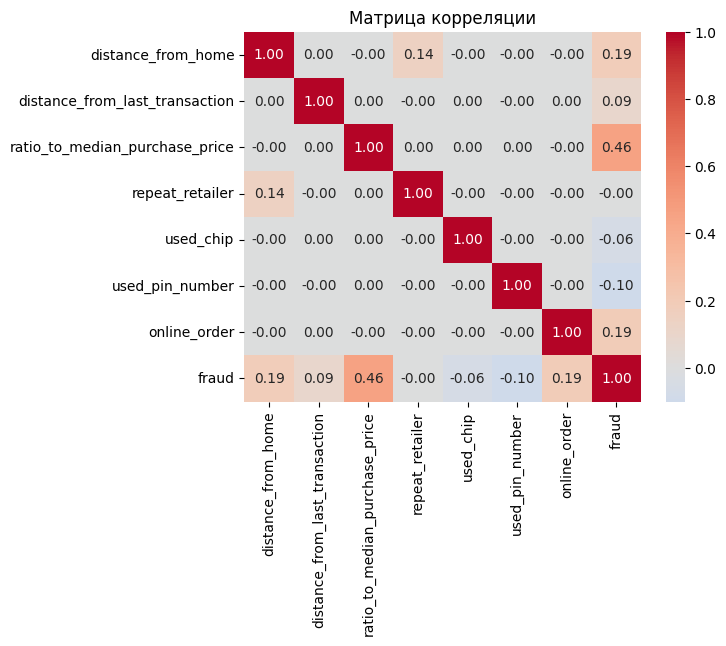

In [37]:
sns.heatmap(dataset.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Матрица корреляции")
plt.show()

Выводы:
1. Все нецелевые признаки практически не коррелируют друг с другом. За исключением пары признаков `distance_from_home` и `repeat_retailer`, которые имеют небольшую положительную корреляцию. Можно считать, что между признаками отсутсвует мультиколлинеарность.
2. Наибольшую корреляцию целевой признак имеет с признаком `ratio_to_median_purchase_price` (положительная)
3. Вторыми по силе корреляции с целевым признаком являются признаки `ratio_to_median_purchase_price` и `online_order` (положительные корреляции).
4. Целевой признак имеет отрицательную корреляцию (т.е. обратную зависимость) с признаком `used_pin_number`, что и наблюдалось ранее.
5. Между целевыми признаком и `repeat_retailer` практически отсутствует линейная зависимость.

In [ ]:
#@title Семплирование - случайный отбор
sample_df = dataset.sample(30000)
describeSample = sample_df.describe(include='all')

In [ ]:
sample_df.describe(include='all')

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,30000.000000,30000.000000,30000.000000,30000.0,30000.0,30000.0,30000.0,30000.0
unique,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0
top,NaN,NaN,NaN,1.0,0.0,0.0,1.0,0.0
freq,NaN,NaN,NaN,26523.0,19466.0,26972.0,19600.0,27378.0
mean,26.823122,4.998291,1.829385,NaN,NaN,NaN,NaN,NaN
std,70.666101,26.379932,2.896560,NaN,NaN,NaN,NaN,NaN
min,0.030511,0.000655,0.013079,NaN,NaN,NaN,NaN,NaN
25%,3.914269,0.290498,0.476689,NaN,NaN,NaN,NaN,NaN
50%,9.951307,0.978100,0.991884,NaN,NaN,NaN,NaN,NaN
75%,25.547588,3.344565,2.110577,NaN,NaN,NaN,NaN,NaN


In [ ]:
raz = describeOriginal - describeSample
raz.abs()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,70000.000000,70000.000000,70000.000000,70000.0,70000.0,70000.0,70000.0,70000.0
unique,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
top,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
freq,NaN,NaN,NaN,61686.0,45428.0,62703.0,45466.0,63912.0
mean,0.134636,0.025426,0.010011,NaN,NaN,NaN,NaN,NaN
std,5.534023,1.940513,0.016289,NaN,NaN,NaN,NaN,NaN
min,0.009189,0.000167,0.001706,NaN,NaN,NaN,NaN,NaN
25%,0.049378,0.005317,0.000297,NaN,NaN,NaN,NaN,NaN
50%,0.013974,0.018595,0.004197,NaN,NaN,NaN,NaN,NaN
75%,0.179189,0.011501,0.021561,NaN,NaN,NaN,NaN,NaN


In [ ]:
fr_repeat_retailer = 26523/30000
fr_used_chip = 26523/30000
fr_used_pin_number = 26972/30000
fr_online_order = 19600/30000
fr_fraud = 27378/30000
print('Относительная частота для признака repeat_retailer\t' + str(fr_repeat_retailer))
print('Относительная частота для признака used_chip\t\t' + str(fr_used_chip))
print('Относительная частота для признака used_pin_number\t' + str(fr_used_pin_number))
print('Относительная частота для признака online_order\t\t' + str(fr_online_order))
print('Относительная частота для признака fraud\t\t' + str(fr_fraud))

Относительная частота для признака repeat_retailer	0.8841
Относительная частота для признака used_chip		0.8841
Относительная частота для признака used_pin_number	0.8990666666666667
Относительная частота для признака online_order		0.6533333333333333
Относительная частота для признака fraud		0.9126


In [ ]:
fr_or_repeat_retailer = 88209/100000
fr_or_used_chip = 64894/100000
fr_or_used_pin_number = 89675/100000
fr_or_online_order = 65066/100000
fr_or_fraud = 91290/100000
print('Абсолютная разность для признака repeat_retailer\t{:.4f}'.format(abs(fr_repeat_retailer - fr_or_repeat_retailer)))
print('Абсолютная разность для признака used_chip\t\t{:.4f}'.format(abs(fr_used_chip - fr_or_used_chip)))
print('Абсолютная разность для признака used_pin_number\t{:.4f}'.format(abs(fr_used_pin_number - fr_or_used_pin_number)))
print('Абсолютная разность для признака online_order\t\t{:.4f}'.format(abs(fr_online_order - fr_or_online_order)))
print('Абсолютная разность для признака fraud\t\t\t{:.4f}'.format(abs(fr_fraud - fr_or_fraud)))

Абсолютная разность для признака repeat_retailer	0.0020
Абсолютная разность для признака used_chip		0.2352
Абсолютная разность для признака used_pin_number	0.0023
Абсолютная разность для признака online_order		0.0027
Абсолютная разность для признака fraud			0.0003


In [ ]:
df_sample = dataset.groupby(["repeat_retailer", "used_chip","used_pin_number", "online_order","fraud"], group_keys=False).apply(lambda x:x.sample(frac=0.3))
str_s = df_sample.describe(include = 'all')
raz = describeOriginal - str_s
raz.abs()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,70001.000000,70001.000000,70001.000000,70001.0,70001.0,70001.0,70001.0,70001.0
unique,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
top,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
freq,NaN,NaN,NaN,61746.0,45427.0,62773.0,45546.0,63905.0
mean,0.268506,0.179590,0.002376,NaN,NaN,NaN,NaN,NaN
std,8.759064,3.749530,0.229833,NaN,NaN,NaN,NaN,NaN
min,0.021012,0.000386,0.003301,NaN,NaN,NaN,NaN,NaN
25%,0.071294,0.006146,0.002466,NaN,NaN,NaN,NaN,NaN
50%,0.121602,0.011459,0.004780,NaN,NaN,NaN,NaN,NaN
75%,0.321541,0.066610,0.009026,NaN,NaN,NaN,NaN,NaN


In [ ]:
str_s

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,29999.000000,29999.000000,29999.000000,29999.0,29999.0,29999.0,29999.0,29999.0
unique,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0
top,NaN,NaN,NaN,1.0,0.0,0.0,1.0,0.0
freq,NaN,NaN,NaN,26463.0,19467.0,26902.0,19520.0,27385.0
mean,26.956993,4.844126,1.816997,NaN,NaN,NaN,NaN,NaN
std,73.891142,20.689889,3.142682,NaN,NaN,NaN,NaN,NaN
min,0.042333,0.000874,0.014674,NaN,NaN,NaN,NaN,NaN
25%,3.793597,0.289669,0.473926,NaN,NaN,NaN,NaN,NaN
50%,9.843679,0.985236,0.991300,NaN,NaN,NaN,NaN,NaN
75%,25.405236,3.266454,2.079990,NaN,NaN,NaN,NaN,NaN


In [ ]:
raz = describeSample - str_s
raz.abs()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0
unique,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
top,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0
freq,NaN,NaN,NaN,60.0,1.0,70.0,80.0,7.0
mean,0.133871,0.154164,0.012388,NaN,NaN,NaN,NaN,NaN
std,3.225041,5.690043,0.246122,NaN,NaN,NaN,NaN,NaN
min,0.011822,0.000219,0.001595,NaN,NaN,NaN,NaN,NaN
25%,0.120672,0.000829,0.002763,NaN,NaN,NaN,NaN,NaN
50%,0.107628,0.007136,0.000584,NaN,NaN,NaN,NaN,NaN
75%,0.142352,0.078111,0.030587,NaN,NaN,NaN,NaN,NaN


In [ ]:
fr_str_repeat_retailer = 26463.0/30000
fr_str_used_chip = 19467.0/30000
fr_str_used_pin_number = 26902.0/30000
fr_str_online_order = 19520.0/30000
fr_str_fraud = 27385.0/30000
print('Относительная частота для признака repeat_retailer\t' + str(fr_str_repeat_retailer))
print('Относительная частота для признака used_chip\t\t' + str(fr_str_used_chip))
print('Относительная частота для признака used_pin_number\t' + str(fr_str_used_pin_number))
print('Относительная частота для признака online_order\t\t' + str(fr_str_online_order))
print('Относительная частота для признака fraud\t\t' + str(fr_str_fraud))

Относительная частота для признака repeat_retailer	0.8821
Относительная частота для признака used_chip		0.6489
Относительная частота для признака used_pin_number	0.8967333333333334
Относительная частота для признака online_order		0.6506666666666666
Относительная частота для признака fraud		0.9128333333333334


In [ ]:
print('Абсолютная разность для признака repeat_retailer\t{:.4f}'.format(abs(fr_str_repeat_retailer - fr_or_repeat_retailer)))
print('Абсолютная разность для признака used_chip\t\t{:.4f}'.format(abs(fr_str_used_chip - fr_or_used_chip)))
print('Абсолютная разность для признака used_pin_number\t{:.4f}'.format(abs(fr_str_used_pin_number - fr_or_used_pin_number)))
print('Абсолютная разность для признака online_order\t\t{:.4f}'.format(abs(fr_str_online_order - fr_or_online_order)))
print('Абсолютная разность для признака fraud\t\t\t{:.4f}'.format(abs(fr_str_fraud - fr_or_fraud)))

Абсолютная разность для признака repeat_retailer	0.0000
Абсолютная разность для признака used_chip		0.0000
Абсолютная разность для признака used_pin_number	0.0000
Абсолютная разность для признака online_order		0.0000
Абсолютная разность для признака fraud			0.0001


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(dataset.iloc[:,:-1], dataset.iloc[:, -1], test_size = 0.2, random_state = 17, shuffle = True, stratify = dataset.iloc[:,-1])

In [ ]:
gboost = GradientBoostingClassifier()
gboost.fit(X_train, y_train)
pred_y = gboost.predict(X_test)

In [ ]:
accuracy_score(y_test, pred_y)

0.99935

In [ ]:
f1_score(y_test, pred_y)

0.9962589928057554

In [ ]:
logistic_regression = LogisticRegression(max_iter = 100000, solver = 'newton-cholesky')
logistic_regression.fit(X_train, y_train)
log_pred_y = logistic_regression.predict(X_test)

In [ ]:
accuracy_score(y_test, log_pred_y)

0.9564

In [ ]:
f1_score(y_test, log_pred_y)

0.6933895921237694

In [ ]:
random_forest = RandomForestClassifier()
random_forest.fit(X_train, y_train)
rf_pred_y = random_forest.predict(X_test)

In [ ]:
accuracy_score(y_test, rf_pred_y)

0.9998

In [ ]:
f1_score(y_test, rf_pred_y)

0.9988512349224584

# Заметки

**Отличие среднего значения от медианы**

Среднее и Медиана — два часто используемых термина в математике, среднее значение похоже на среднее значение заданных чисел, оно суммирует числа и делит их на количество чисел, которое дает нам среднее значение, в то время как медиана, с другой стороны, возвращает среднее число из всего набора данных и если набор данных четный, то медиана складывает два средних числа и делит их на 2, получая медиану.

**Что такое квантиль**

В статистике и вероятности квантили-это точки среза, делящие диапазон распределения вероятностей на непрерывные интервалы с равными вероятностями или делящие наблюдения в выборке таким же образом


https://tproger.ru/translations/statistics-for-data-scientists/